# Chapter 9 — AutoML drought-impact prediction

Automated search over **models**, **predictor groups / within-group subsets**, and **hyperparameters** for multi-label NUTS-3 drought-impact forecasting.

**Problem setup (thesis):**
- Spatial unit: NUTS-3
- Horizons: $h \in \{0,1,2,3\}$ months; **selection criterion** = mean expanding-window CV **macro PR-AUC at $h=1$**
- Targets: top-10 impact classes (Binary Relevance)
- Development: 2018–2023 (year expanding CV); independent test: 2024–2025
- Post-hoc XAI: SHAP
- `year` is **not** used as a predictor (only for temporal CV splits); seasonality uses `month_sin` / `month_cos`

**Data:** prepared panels from `Data_preparation_prediction.ipynb` (not rebuilt here).

---

## Evaluation metrics

Drought impacts are rare (~5–15% positive months per class), so ranking metrics matter more than accuracy.

| Metric | Role |
|--------|------|
| **PR-AUC** (average precision) | **Primary.** Area under the precision–recall curve; focuses on identifying the positive (impact) class under imbalance. |
| **Macro PR-AUC** | Unweighted mean of PR-AUC over the 10 impact classes. **Optuna selection criterion** at $h=1$ (mean over expanding-window folds). |
| **ROC-AUC** | Secondary ranking metric; can look optimistic when negatives dominate. |
| **Brier score** | Mean squared error of predicted probabilities (lower is better); calibration quality. |
| **Precision / recall / F1** | Thresholded at 0.5; useful for operating-point intuition, not for model selection here. |
| **Prevalence** | Positive rate $P(y=1)$. A trivial classifier that always ranks positives by chance has PR-AUC ≈ prevalence. |
| **PR-AUC skill** | $\mathrm{PR\text{-}AUC} - \mathrm{prevalence}$: lift over that naive baseline. |

**Why not accuracy / ROC alone?** A model that always predicts “no impact” can achieve high accuracy and often strong ROC-AUC while never detecting impacts. PR-AUC penalises that failure mode and matches the operational goal of anticipating rare drought impacts.


## 0. Setup

In [18]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from IPython.display import display
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

PACKAGE_ROOT = Path("..").resolve()
if not (PACKAGE_ROOT / "src" / "automl_search.py").exists():
    PACKAGE_ROOT = Path(".").resolve()
    if PACKAGE_ROOT.name == "notebooks":
        PACKAGE_ROOT = PACKAGE_ROOT.parent

sys.path.insert(0, str(PACKAGE_ROOT / "src"))

from automl_search import (
    FORECAST_HORIZONS,
    TOP_10_CLASSES,
    best_config_from_study,
    cv_score_config,
    evaluate_config_all_horizons,
    export_temporal_spatial_diagnostics,
    load_feature_groups,
    macro_from_class_metrics,
    make_optuna_objective,
    shap_mean_abs_importance,
    trials_dataframe,
    year_expanding_folds,
)

OUT_DIR = PACKAGE_ROOT / "data" / "processed"
RESULT_DIR = PACKAGE_ROOT / "results" / "automl_results"
FIG_DIR = RESULT_DIR / "figures"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_TRIALS = 100
RANDOM_SEED = 42
PRIMARY_HORIZON = 1
SHAP_N_MODELS_THRESHOLD = 0.05

print(f"Package: {PACKAGE_ROOT}")
print(f"Panels:  {OUT_DIR}")
print(f"Results: {RESULT_DIR}")


Package: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting
Panels:  C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed
Results: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results


In [2]:
# Ensure Optuna is available
try:
    import optuna
except ImportError:
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna

from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("optuna", optuna.__version__)


optuna 4.9.0


In [3]:
import importlib

import automl_search

automl_search = importlib.reload(automl_search)

from automl_search import (
    TOP_10_CLASSES,
    FORECAST_HORIZONS,
    BestConfig,
    best_config_from_study,
    cv_score_config,
    evaluate_config_all_horizons,
    export_temporal_spatial_diagnostics,
    load_feature_groups,
    macro_from_class_metrics,
    make_optuna_objective,
    metrics_by_group,
    macro_metrics_over_classes,
    build_prediction_long,
    shap_mean_abs_importance,
    trials_dataframe,
    year_expanding_folds,
)

print(f"Classes: {len(TOP_10_CLASSES)}")
print(f"Horizons: {FORECAST_HORIZONS}")
print(f"Excluded features: {automl_search.EXCLUDED_FEATURES}")


Classes: 10
Horizons: [0, 1, 2, 3]
Excluded features: {'year'}


## 1. Load prepared panels and feature groups

Uses complete-case development / test exports and `feature_manifest.csv` group labels.


In [4]:
dev = pd.read_parquet(OUT_DIR / "dev_nuts3_forecast_2018_2023.parquet")
test = pd.read_parquet(OUT_DIR / "test_nuts3_forecast_2024_2025.parquet")
feature_groups = load_feature_groups(OUT_DIR / "feature_manifest.csv")

# Defensive: strip year even if an old automl_search was cached in the kernel
for g, cols in list(feature_groups.items()):
    feature_groups[g] = [c for c in cols if c != "year"]

dev["year_month"] = pd.to_datetime(dev["year_month"])
test["year_month"] = pd.to_datetime(test["year_month"])
if "year" not in dev.columns:
    dev["year"] = dev["year_month"].dt.year
if "year" not in test.columns:
    test["year"] = test["year_month"].dt.year

print(
    f"Development: {dev.shape}  |  "
    f"{dev['year_month'].min():%Y-%m} -> {dev['year_month'].max():%Y-%m}"
)
print(
    f"Test:        {test.shape}  |  "
    f"{test['year_month'].min():%Y-%m} -> {test['year_month'].max():%Y-%m}"
)
print("\nFeature groups (year excluded from temporal):")
for g, cols in feature_groups.items():
    print(f"  {g:14s} {len(cols):3d}")
assert "year" not in feature_groups.get("temporal", []), "year must not be a model feature"


Development: (2877, 102)  |  2018-01 -> 2023-12
Test:        (837, 102)  |  2024-01 -> 2025-09

Feature groups (year excluded from temporal):
  class_lag       10
  meteo           14
  static_elev      2
  static_land      3
  static_pop       1
  static_soil     18
  temporal         3


## 2. Expanding-window temporal CV (thesis figure)

| Fold | Train years | Validation year |
|------|-------------|-----------------|
| 1 | 2018–2019 | 2020 |
| 2 | 2018–2020 | 2021 |
| 3 | 2018–2021 | 2022 |
| 4 | 2018–2022 | 2023 |


In [5]:
folds = year_expanding_folds(dev)
fold_summary = pd.DataFrame(
    [
        {
            "fold": f.fold,
            "train_years": f"{f.train_years[0]}-{f.train_years[-1]}",
            "valid_year": f.valid_year,
            "n_train": len(f.train_idx),
            "n_valid": len(f.val_idx),
        }
        for f in folds
    ]
)
display(fold_summary)
assert len(folds) == 4, "Expected 4 year-expanding folds"


,fold,train_years,valid_year,n_train,n_valid
0,1,2018-2019,2020,960,480
1,2,2018-2020,2021,1440,477
2,3,2018-2021,2022,1917,480
3,4,2018-2022,2023,2397,480


## 3. Optuna AutoML search

Search space:
- **Models:** Logistic Regression, Elastic Net, Random Forest, XGBoost, CatBoost
- **Predictor groups (all optional):** meteo, temporal, land, population, elevation, soil, class lags
- **Within-group subsets** when a group is on (e.g. SPI-only / SPEI-only / short–long scales; soil organic / sand–podzol / clay–loam; seasonal vs persistence temporal features). `year` is never a feature.
- **Hyperparameters:** wider model-conditional ranges
- **Objective:** mean fold **macro PR-AUC** at $h=1$


In [6]:
sampler = TPESampler(seed=RANDOM_SEED)
pruner = MedianPruner(n_startup_trials=8, n_warmup_steps=1)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name="ch9_drought_impact_automl",
)

objective = make_optuna_objective(
    dev,
    feature_groups,
    folds,
    horizon=PRIMARY_HORIZON,
    classes=TOP_10_CLASSES,
)

print(f"Starting Optuna search: {N_TRIALS} trials (primary horizon h={PRIMARY_HORIZON})...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial #{study.best_trial.number}: macro PR-AUC h=1 = {study.best_value:.4f}")
print(f"Best model: {study.best_trial.params['model']}")
print(f"n_features: {study.best_trial.user_attrs.get('n_features')}")
print(f"groups: {study.best_trial.user_attrs.get('feature_groups_used')}")
print(f"group_subsets: {study.best_trial.user_attrs.get('group_subsets')}")


Starting Optuna search: 100 trials (primary horizon h=1)...


Best trial: 88. Best value: 0.33502: 100%|██████████| 100/100 [10:18<00:00,  6.19s/it]


Best trial #88: macro PR-AUC h=1 = 0.3350
Best model: logistic_regression
n_features: 30
groups: ['meteo', 'temporal', 'static_elev', 'static_soil']
group_subsets: {'meteo': 'long', 'temporal': 'seasonality', 'static_elev': 'both', 'static_soil': 'all'}


In [7]:
trials_df = trials_dataframe(study)
trials_df.to_csv(RESULT_DIR / "cv_trials.csv", index=False)
display(trials_df.head(15))

best = best_config_from_study(study)
best.save(RESULT_DIR / "best_config.json")
pd.DataFrame({"feature": best.features}).to_csv(RESULT_DIR / "selected_features.csv", index=False)

print("Saved best_config.json and selected_features.csv")
print(json.dumps({k: v for k, v in best.to_dict().items() if k != "features"}, indent=2))
print(f"\nSelected features ({len(best.features)}):")
print(best.features)


,trial,state,macro_pr_auc_h1,model,n_features,feature_groups,group_subsets,subset_meteo,subset_static_pop,subset_static_elev,...,param_class_lag_subset,param_max_depth,param_n_estimators,param_min_samples_leaf,param_iterations,param_depth,param_learning_rate,param_l2_leaf_reg,param_subsample,param_colsample_bytree
89,89,TrialState.PRUNED,0.433309,logistic_regression,14,"meteo,temporal,static_elev,static_soil","{""meteo"": ""long"", ""static_elev"": ""both"", ""stat...",long,NaN,both,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,69,TrialState.PRUNED,0.420339,xgboost,37,"meteo,temporal,static_elev,static_soil","{""meteo"": ""all"", ""static_elev"": ""both"", ""stati...",all,NaN,both,...,NaN,4.0,200.0,NaN,NaN,NaN,0.026526,NaN,0.650469,0.664730
98,98,TrialState.PRUNED,0.417128,logistic_regression,27,"meteo,static_elev,static_soil","{""meteo"": ""long"", ""static_elev"": ""mean_only"", ...",long,NaN,mean_only,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,97,TrialState.PRUNED,0.414790,logistic_regression,18,"meteo,temporal,static_elev,static_soil","{""meteo"": ""long"", ""static_elev"": ""both"", ""stat...",long,NaN,both,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,75,TrialState.PRUNED,0.411894,logistic_regression,29,"meteo,temporal,static_elev,static_soil,class_lag","{""class_lag"": ""agriculture"", ""meteo"": ""all"", ""...",all,NaN,both,...,agriculture,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,80,TrialState.PRUNED,0.409975,random_forest,14,"meteo,static_elev,static_soil,class_lag","{""class_lag"": ""fire"", ""meteo"": ""spi_only"", ""st...",spi_only,NaN,both,...,fire,13.0,600.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
90,90,TrialState.PRUNED,0.404910,xgboost,12,"meteo,temporal,static_elev","{""meteo"": ""long"", ""static_elev"": ""both"", ""temp...",long,NaN,both,...,NaN,7.0,450.0,NaN,NaN,NaN,0.041281,NaN,0.995927,0.692043
79,79,TrialState.PRUNED,0.400641,logistic_regression,27,"temporal,static_elev,static_soil,class_lag","{""class_lag"": ""agriculture"", ""static_elev"": ""b...",NaN,NaN,both,...,agriculture,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,29,TrialState.PRUNED,0.394302,random_forest,27,"meteo,static_elev,static_soil,class_lag","{""class_lag"": ""all"", ""meteo"": ""all"", ""static_e...",all,NaN,both,...,all,16.0,500.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN
45,45,TrialState.PRUNED,0.392386,logistic_regression,9,"meteo,temporal,static_elev,static_soil","{""meteo"": ""aux_only"", ""static_elev"": ""std_only...",aux_only,NaN,std_only,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved best_config.json and selected_features.csv
{
  "model_name": "logistic_regression",
  "params": {
    "C": 0.03384313229479467
  },
  "cv_macro_pr_auc": 0.33501974879731256,
  "trial_number": 88,
  "feature_groups_used": [
    "meteo",
    "temporal",
    "static_elev",
    "static_soil"
  ],
  "group_subsets": {
    "meteo": "long",
    "temporal": "seasonality",
    "static_elev": "both",
    "static_soil": "all"
  }
}

Selected features (30):
['spei_09', 'spei_12', 'spei_24', 'spi_09', 'spi_12', 'spi_24', 'soil_moisture_anom', 'cdd_days', 'month_sin', 'month_cos', 'elevation_mean', 'elevation_std', 'soil_brikgronden', 'soil_dikke_eerdgronden', 'soil_gedefinieerde_associaties', 'soil_kalkhoudende_zandgronden', 'soil_kalkloze_zandgronden', 'soil_kalksteen_verweringsgronden', 'soil_keileemgronden', 'soil_leemgronden', 'soil_moerige_gronden', 'soil_niet_gerijpte_minerale_gronden', 'soil_oude_rivierkleigronden', 'soil_podzolgronden', 'soil_rivierkleigronden', 'soil_veengronden', 's

In [8]:
# CV fold scores for the winning configuration (transparency)
cv_best = cv_score_config(dev, best, folds, horizon=PRIMARY_HORIZON)
cv_best.to_csv(RESULT_DIR / "best_config_cv_folds.csv", index=False)
display(cv_best)
print(
    f"Mean CV macro PR-AUC h=1: "
    f"{cv_best['macro_pr_auc'].mean():.4f} ± {cv_best['macro_pr_auc'].std():.4f}"
)

top_by_model = (
    trials_df.dropna(subset=["macro_pr_auc_h1"])
    .groupby("model", as_index=False)["macro_pr_auc_h1"]
    .max()
    .sort_values("macro_pr_auc_h1", ascending=False)
)
display(top_by_model)


,fold,train_years,valid_year,macro_pr_auc,horizon
0,1,2018-2019,2020,0.485453,1
1,2,2018-2019-2020,2021,0.157670,1
2,3,2018-2019-2020-2021,2022,0.373375,1
3,4,2018-2019-2020-2021-2022,2023,0.323581,1


Mean CV macro PR-AUC h=1: 0.3350 ± 0.1362


,model,macro_pr_auc_h1
2,logistic_regression,0.433309
4,xgboost,0.420339
3,random_forest,0.409975
0,catboost,0.384080
1,elastic_net,0.338400


## 4. Retrain on full development (2018–2023) and evaluate on test (2024–2025)

The selected configuration is retrained separately per horizon $h \in \{0,1,2,3\}$ on all development data, then scored on the independent test period.


In [9]:
test_metrics, models_by_h, proba_by_h = evaluate_config_all_horizons(
    dev,
    test,
    best,
    horizons=FORECAST_HORIZONS,
    classes=TOP_10_CLASSES,
)

test_metrics.to_csv(RESULT_DIR / "test_metrics_by_class_horizon.csv", index=False)
macro_test = macro_from_class_metrics(test_metrics)
macro_test.to_csv(RESULT_DIR / "test_macro_by_horizon.csv", index=False)

print("Test macro metrics by horizon:")
display(macro_test.round(4))

print("\nPer-class PR-AUC at h=1:")
display(
    test_metrics.loc[test_metrics["horizon"] == 1, ["class", "pr_auc", "roc_auc", "f1", "prevalence"]]
    .sort_values("pr_auc", ascending=False)
    .round(4)
)


Test macro metrics by horizon:


,horizon,macro_pr_auc,macro_roc_auc,macro_precision,macro_recall,macro_f1,macro_brier,macro_prevalence
0,0,0.3033,0.7624,0.1686,0.7417,0.2690,0.2268,0.0931
1,1,0.2590,0.7499,0.1684,0.7026,0.2646,0.2146,0.0909
2,2,0.2248,0.7196,0.1505,0.7366,0.2450,0.2468,0.0939
3,3,0.2303,0.7119,0.1658,0.6872,0.2609,0.2165,0.0953



Per-class PR-AUC at h=1:


,class,pr_auc,roc_auc,f1,prevalence
10,Crop Failure & Yield Reduction,0.4926,0.7924,0.4276,0.1481
14,Water Use Restrictions,0.4047,0.8000,0.2526,0.0585
17,Irrigation Shortage,0.2972,0.7809,0.2648,0.0884
13,Groundwater Depletion,0.2766,0.7165,0.2742,0.1087
18,Water Supply & Sanitation Issues,0.2447,0.7449,0.2407,0.1111
15,Forest Dieback & Vegetation Stress,0.2171,0.6978,0.3127,0.1111
16,Agricultural Economic Loss,0.2065,0.8260,0.1533,0.0346
11,Reservoir & Surface Water Shortage,0.2028,0.7466,0.3313,0.1027
12,Freshwater Ecosystem Degradation,0.1651,0.6225,0.2589,0.1171
19,Wildfire Occurrence,0.0825,0.7713,0.1300,0.0287


,class,pr_auc,prevalence,pr_auc_skill
14,Water Use Restrictions,0.4047,0.0585,0.3461
10,Crop Failure & Yield Reduction,0.4926,0.1481,0.3445
17,Irrigation Shortage,0.2972,0.0884,0.2088
16,Agricultural Economic Loss,0.2065,0.0346,0.1719
13,Groundwater Depletion,0.2766,0.1087,0.1679
18,Water Supply & Sanitation Issues,0.2447,0.1111,0.1336
15,Forest Dieback & Vegetation Stress,0.2171,0.1111,0.1060
11,Reservoir & Surface Water Shortage,0.2028,0.1027,0.1001
19,Wildfire Occurrence,0.0825,0.0287,0.0539
12,Freshwater Ecosystem Degradation,0.1651,0.1171,0.0481


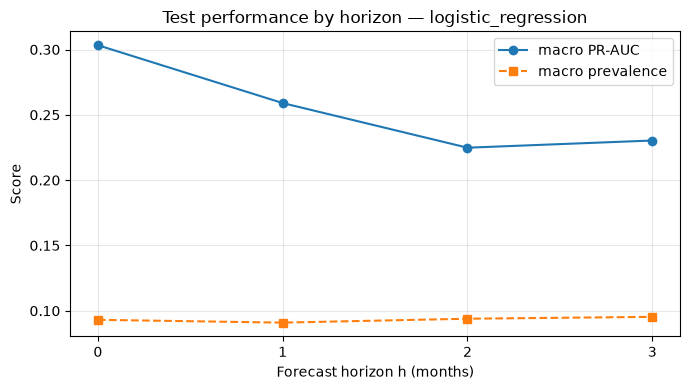

In [10]:
# Prevalence baseline skill: PR-AUC - prevalence
skill = test_metrics.copy()
skill["pr_auc_skill"] = skill["pr_auc"] - skill["prevalence"]
skill_h1 = skill.loc[
    skill["horizon"] == 1, ["class", "pr_auc", "prevalence", "pr_auc_skill"]
].sort_values("pr_auc_skill", ascending=False)
display(skill_h1.round(4))
skill.to_csv(RESULT_DIR / "test_metrics_with_skill.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(macro_test["horizon"], macro_test["macro_pr_auc"], marker="o", label="macro PR-AUC")
ax.plot(
    macro_test["horizon"],
    macro_test["macro_prevalence"],
    marker="s",
    linestyle="--",
    label="macro prevalence",
)
ax.set_xlabel("Forecast horizon h (months)")
ax.set_ylabel("Score")
ax.set_xticks(FORECAST_HORIZONS)
ax.set_title(f"Test performance by horizon — {best.model_name}")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_test_macro_by_horizon.png", dpi=150)
plt.show()


## 5. Post-hoc XAI (SHAP)

Mean absolute SHAP values aggregated across the ten Binary Relevance models at $h=1$.


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP val

,feature,mean_abs_shap,n_models,n_models_evaluated
0,spei_09,0.894891,10,10
1,spi_12,0.754351,10,10
2,month_cos,0.669581,10,10
3,spi_09,0.291017,8,10
4,soil_moerige_gronden,0.266734,10,10
5,spei_12,0.247168,8,10
6,cdd_days,0.172666,9,10
7,month_sin,0.150155,9,10
8,soil_podzolgronden,0.138410,8,10
9,soil_kalkhoudende_zandgronden,0.113380,10,10


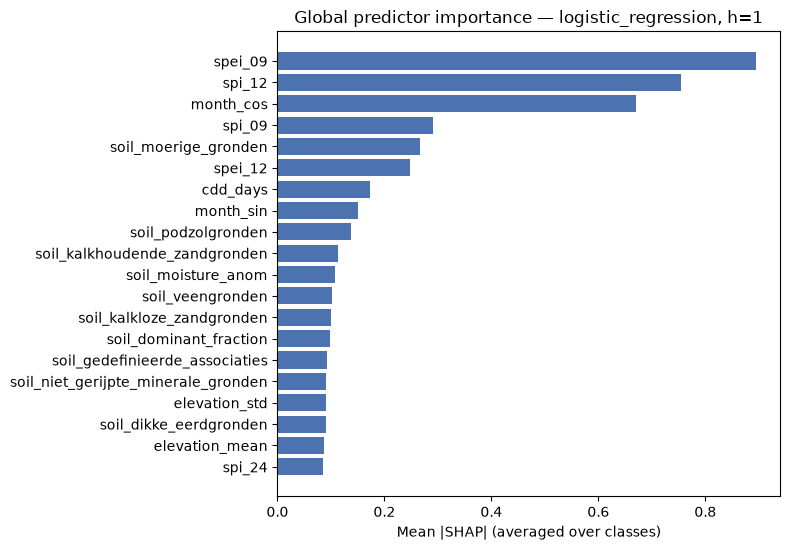

In [11]:
models_h1 = models_by_h[PRIMARY_HORIZON]
shap_imp = shap_mean_abs_importance(
    models_h1,
    test,
    best.features,
    model_name=best.model_name,
    max_samples=400,
    max_bg=200,
    shap_threshold=SHAP_N_MODELS_THRESHOLD,
)
shap_imp.to_csv(RESULT_DIR / "shap_importance_h1.csv", index=False)
display(shap_imp.head(20))

top_n = min(20, len(shap_imp))
plot_df = shap_imp.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.28)))
ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color="#4C72B0")
ax.set_xlabel("Mean |SHAP| (averaged over classes)")
ax.set_title(f"Global predictor importance — {best.model_name}, h={PRIMARY_HORIZON}")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_shap_importance_h1.png", dpi=150)
plt.show()


## 6. Error diagnostics (time & space)

Post-hoc diagnostics on **held-out test** predictions at $h=1$ (reuse `proba_by_h[1]`).

**Caveat:** the test window is short (~21 months), so year-level claims are weak. Calendar month, SPEI-12 drought bins, and JJA regional maps are the main signals for off-drought vs drought and summer spatial skill.

**Metric rules per slice:** always report $n$, positives, prevalence, mean predicted probability, and Brier. PR-AUC and skill ($\mathrm{PR\text{-}AUC}-\mathrm{prevalence}$) only if both classes appear and $\ge 5$ positives. Overall views macro-average PR-AUC/skill over classes with a valid PR-AUC in that slice.

**Drought bins (SPEI-12):** dry $\le -1$; near-normal $(-1,1)$; wet $\ge 1$. Expectation: worse skill / higher Brier off-drought.


### 6.1 Temporal performance

In [12]:
# Long prediction frame + full diagnostic export (CSVs + figures)
proba_h1 = proba_by_h[PRIMARY_HORIZON]
diag_paths = export_temporal_spatial_diagnostics(
    test,
    proba_h1,
    TOP_10_CLASSES,
    RESULT_DIR,
    horizon=PRIMARY_HORIZON,
    notebook_dir=PACKAGE_ROOT,
)
print("Wrote diagnostics:")
for k, p in diag_paths.items():
    print(f"  {k}: {p.relative_to(RESULT_DIR)}")

pred_long = build_prediction_long(test, proba_h1, TOP_10_CLASSES, horizon=PRIMARY_HORIZON)
print(f"\nLong frame: {pred_long.shape[0]:,} rows  |  classes={pred_long['class'].nunique()}  |  months={pred_long['year_month'].nunique()}")


Wrote diagnostics:
  prediction_long: diag_prediction_long_h1.csv
  temporal_by_month: diag_temporal_by_month.csv
  fig_temporal_by_month: figures\fig_diag_temporal_by_month.png
  temporal_by_calendar_month: diag_temporal_by_calendar_month.csv
  fig_temporal_by_calendar_month: figures\fig_diag_temporal_by_calendar_month.png
  temporal_by_drought_bin: diag_temporal_by_drought_bin.csv
  fig_temporal_by_drought_bin: figures\fig_diag_temporal_by_drought_bin.png
  spatial_by_nuts3: diag_spatial_by_nuts3.csv
  fig_spatial_choropleth: figures\fig_spatial_skill_choropleth.png
  class_by_calendar_month: diag_class_by_calendar_month.csv
  fig_class_by_calendar_month: figures\fig_diag_class_by_calendar_month.png
  class_by_drought_bin: diag_class_by_drought_bin.csv
  fig_class_by_drought_bin: figures\fig_diag_class_by_drought_bin.png
  class_by_nuts3: diag_class_by_nuts3.csv
  class_nuts3_top_bottom: diag_class_nuts3_top_bottom.csv
  spatial_jja_by_nuts3: diag_spatial_jja_by_nuts3.csv
  fig_spati

By year-month (tail):


,year_month,n,n_pos,n_classes,n_classes_pr,macro_prevalence,macro_mean_pred,macro_brier,macro_pr_auc,macro_skill
13,2025-02-01,400.0,17.0,10.0,0.0,0.0425,0.3215,0.1535,NaN,NaN
14,2025-03-01,400.0,68.0,10.0,8.0,0.1700,0.5404,0.2821,0.4784,0.2691
15,2025-04-01,400.0,114.0,10.0,9.0,0.2850,0.5639,0.2890,0.5267,0.2156
16,2025-05-01,400.0,43.0,10.0,5.0,0.1075,0.6754,0.4233,0.4793,0.2993
17,2025-06-01,400.0,147.0,10.0,9.0,0.3675,0.6563,0.3031,0.6179,0.2152
18,2025-07-01,400.0,79.0,10.0,7.0,0.1975,0.5564,0.2799,0.5565,0.3029
19,2025-08-01,400.0,33.0,10.0,3.0,0.0825,0.6067,0.3703,0.5663,0.3746
20,2025-09-01,400.0,13.0,10.0,1.0,0.0325,0.3443,0.1636,0.2940,0.1190



By calendar month:


,month,n,n_pos,n_classes,n_classes_pr,macro_prevalence,macro_mean_pred,macro_brier,macro_pr_auc,macro_skill
0,1,800.0,15.0,10.0,0.0,0.0188,0.2319,0.0868,NaN,NaN
1,2,770.0,28.0,10.0,3.0,0.0364,0.2876,0.1295,0.1475,0.0825
2,3,800.0,95.0,10.0,9.0,0.1188,0.4275,0.2080,0.4187,0.2882
3,4,800.0,135.0,10.0,10.0,0.1688,0.4915,0.2536,0.4105,0.2418
4,5,800.0,66.0,10.0,6.0,0.0825,0.6239,0.3865,0.3735,0.2526
5,6,800.0,169.0,10.0,9.0,0.2112,0.5918,0.2986,0.5386,0.3067
6,7,800.0,106.0,10.0,8.0,0.1325,0.5061,0.2597,0.4346,0.2768
7,8,800.0,48.0,10.0,4.0,0.0600,0.5314,0.3111,0.3435,0.2404
8,9,800.0,38.0,10.0,4.0,0.0475,0.3686,0.1737,0.3090,0.2058
9,10,400.0,9.0,10.0,0.0,0.0225,0.2644,0.1102,NaN,NaN



By drought bin (SPEI-12):


,drought_bin,n,n_pos,n_classes,n_classes_pr,macro_prevalence,macro_mean_pred,macro_brier,macro_pr_auc,macro_skill
0,dry,1410.0,187.0,10.0,9.0,0.1326,0.5061,0.2662,0.3291,0.1849
1,near_normal,1650.0,290.0,10.0,10.0,0.1758,0.5384,0.2884,0.3599,0.1841
2,wet,5310.0,284.0,10.0,10.0,0.0535,0.3594,0.1780,0.1354,0.0819


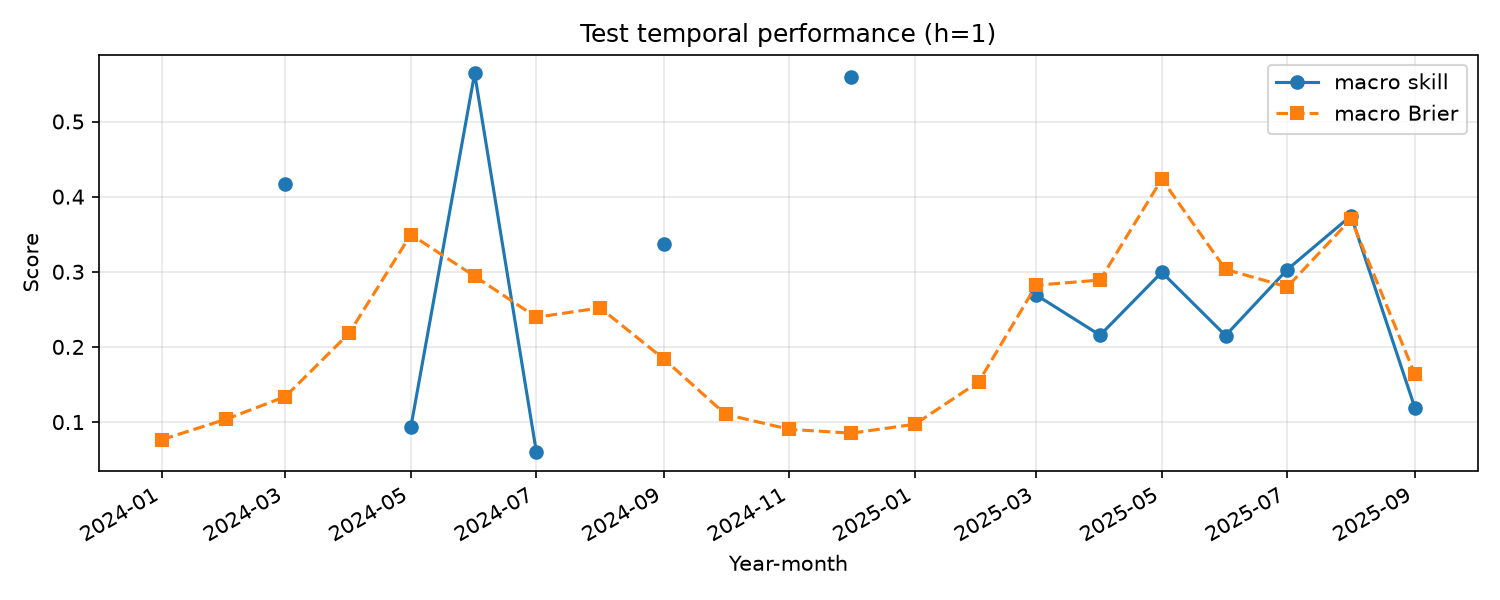

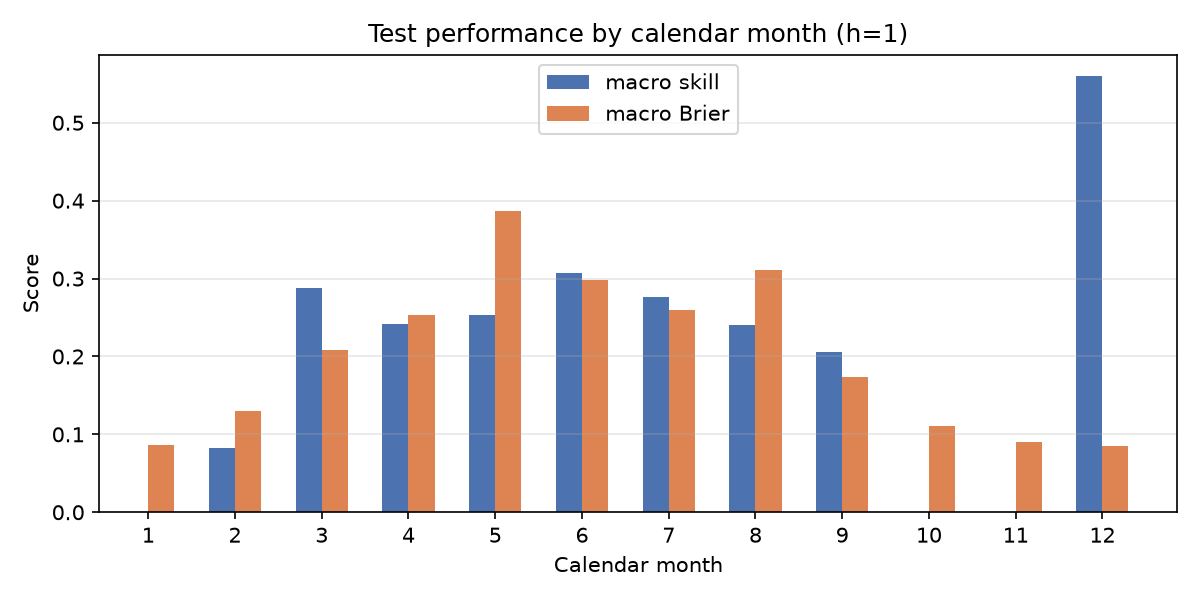

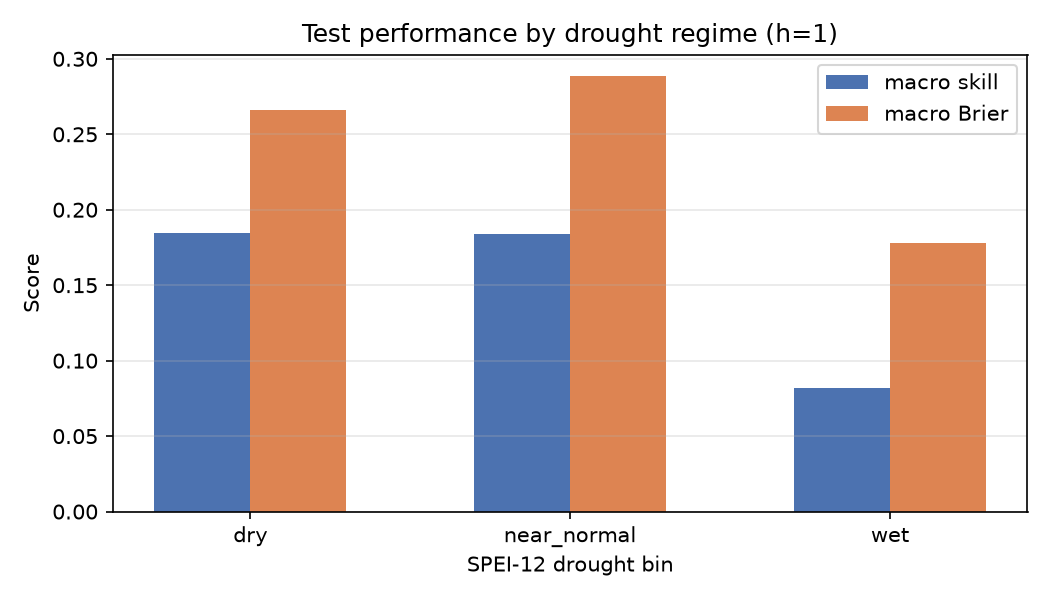

In [13]:
# Inspect temporal tables already exported by export_temporal_spatial_diagnostics
by_ym = pd.read_csv(RESULT_DIR / "diag_temporal_by_month.csv", parse_dates=["year_month"])
by_cal = pd.read_csv(RESULT_DIR / "diag_temporal_by_calendar_month.csv")
by_dry = pd.read_csv(RESULT_DIR / "diag_temporal_by_drought_bin.csv")

print("By year-month (tail):")
display(by_ym.tail(8).round(4))
print("\nBy calendar month:")
display(by_cal.round(4))
print("\nBy drought bin (SPEI-12):")
display(by_dry.round(4))

# Show the figures written to disk
from IPython.display import Image, display as idisplay

for name in [
    "fig_diag_temporal_by_month.png",
    "fig_diag_temporal_by_calendar_month.png",
    "fig_diag_temporal_by_drought_bin.png",
]:
    idisplay(Image(filename=str(FIG_DIR / name)))


### 6.2 Regional performance

Per NUTS-3 macro skill on the full test period (choropleth + ranked table). Regions without enough positives for PR-AUC still contribute Brier; ranking falls back to lower Brier when skill is missing.


Best regions (by skill / Brier fallback):


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos,n_classes_pr
0,NL33C,Groot-Rijnmond,0.6648,0.9029,0.2177,18.0,1.0
1,NL213,Twente,0.4652,0.7033,0.3587,25.0,1.0
2,NL329,Groot-Amsterdam,0.4209,0.6828,0.1478,32.0,4.0
3,NL423,Zuid-Limburg,0.3661,0.6042,0.2519,21.0,1.0
4,NL225,Achterhoek,0.3270,0.5650,0.3442,27.0,2.0
5,NL414,Zuidoost-Noord-Brabant,0.3158,0.6110,0.3356,42.0,5.0
6,NL412,Midden-Noord-Brabant,0.2877,0.6052,0.3294,34.0,3.0
7,NL341,Zeeuwsch-Vlaanderen,0.2617,0.6188,0.2525,37.0,4.0



Worst regions:


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos,n_classes_pr
32,NL124,Noord-Friesland,NaN,NaN,0.1962,20.0,0.0
33,NL33A,Zuidoost-Zuid-Holland,NaN,NaN,0.1979,11.0,0.0
34,NL327,Het Gooi en Vechtstreek,NaN,NaN,0.2023,9.0,0.0
35,NL224,Zuidwest-Gelderland,NaN,NaN,0.2069,12.0,0.0
36,NL112,Delfzijl en omgeving,NaN,NaN,0.2074,8.0,0.0
37,NL226,Arnhem/Nijmegen,NaN,NaN,0.2831,19.0,0.0
38,NL421,Noord-Limburg,NaN,NaN,0.3128,19.0,0.0
39,NL212,Zuidwest-Overijssel,NaN,NaN,0.3364,12.0,0.0


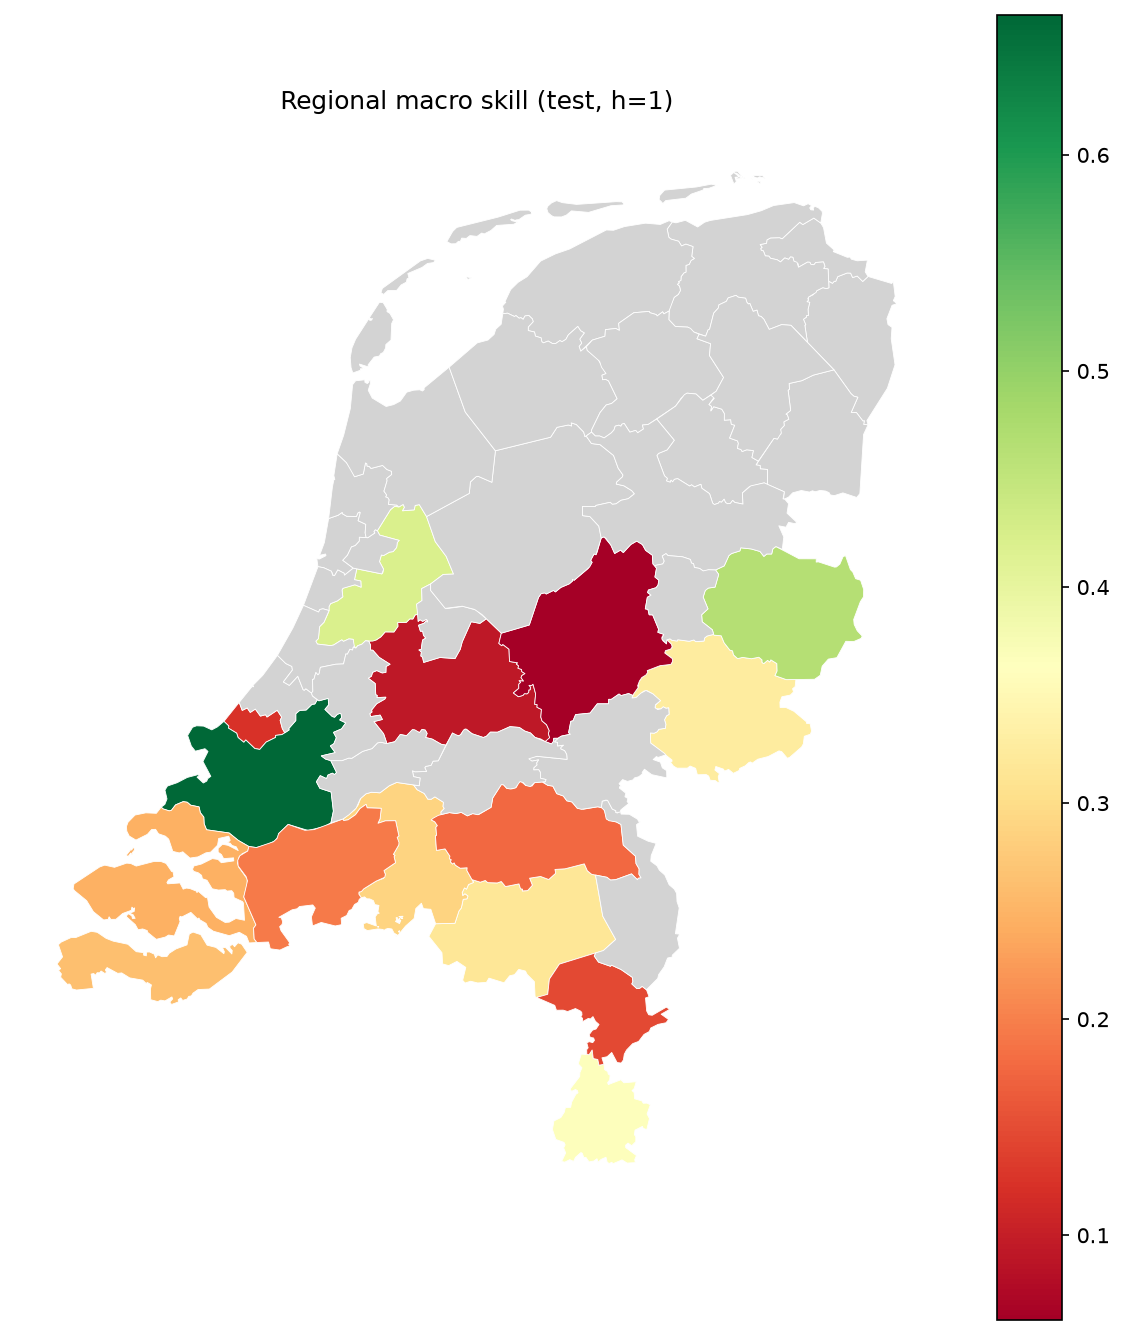

In [14]:
by_nuts = pd.read_csv(RESULT_DIR / "diag_spatial_by_nuts3.csv")
print("Best regions (by skill / Brier fallback):")
display(by_nuts.head(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos", "n_classes_pr"]].round(4))
print("\nWorst regions:")
display(by_nuts.tail(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos", "n_classes_pr"]].round(4))

from IPython.display import Image, display as idisplay

choropleth = FIG_DIR / "fig_spatial_skill_choropleth.png"
if choropleth.exists():
    idisplay(Image(filename=str(choropleth)))
else:
    print("Choropleth figure missing — check geopandas / NUTS geojson path.")


### 6.3 Dependence on impact class

Do temporal and spatial patterns differ by impact type? Heatmaps for class × calendar month and class × drought bin; top/bottom NUTS-3 per class.


Class × drought bin (skill):


drought_bin,dry,near_normal,wet
class,,,
Agricultural Economic Loss,0.1881,0.2453,0.0488
Crop Failure & Yield Reduction,0.3150,0.3724,0.0640
Forest Dieback & Vegetation Stress,0.0497,0.0693,0.2033
Freshwater Ecosystem Degradation,0.2630,0.0442,0.0141
Groundwater Depletion,0.3039,0.1697,0.0740
Irrigation Shortage,0.1564,0.2523,0.1528
Reservoir & Surface Water Shortage,0.0472,0.0098,0.0094
Water Supply & Sanitation Issues,0.2933,0.1170,0.1369
Water Use Restrictions,0.0477,0.5226,0.0536



Top/bottom regions per class (sample):


,class,kind,nuts3_id,nuts3_name,skill,brier,pr_auc,n_pos
0,Agricultural Economic Loss,best,NL342,Overig Zeeland,0.4115,0.2274,0.7925,8.0
1,Agricultural Economic Loss,best,NL341,Zeeuwsch-Vlaanderen,0.2851,0.2859,0.5708,6.0
2,Agricultural Economic Loss,best,NL33B,Oost-Zuid-Holland,NaN,0.0420,NaN,0.0
3,Agricultural Economic Loss,worst,NL221,Veluwe,NaN,0.3363,NaN,1.0
4,Agricultural Economic Loss,worst,NL225,Achterhoek,NaN,0.3360,NaN,2.0
5,Agricultural Economic Loss,worst,NL421,Noord-Limburg,NaN,0.3353,NaN,1.0
6,Crop Failure & Yield Reduction,best,NL33C,Groot-Rijnmond,0.6648,0.2123,0.9029,5.0
7,Crop Failure & Yield Reduction,best,NL329,Groot-Amsterdam,0.5576,0.1305,0.8433,6.0
8,Crop Failure & Yield Reduction,best,NL412,Midden-Noord-Brabant,0.5476,0.2400,0.8333,6.0
9,Crop Failure & Yield Reduction,worst,NL221,Veluwe,NaN,0.3466,NaN,3.0


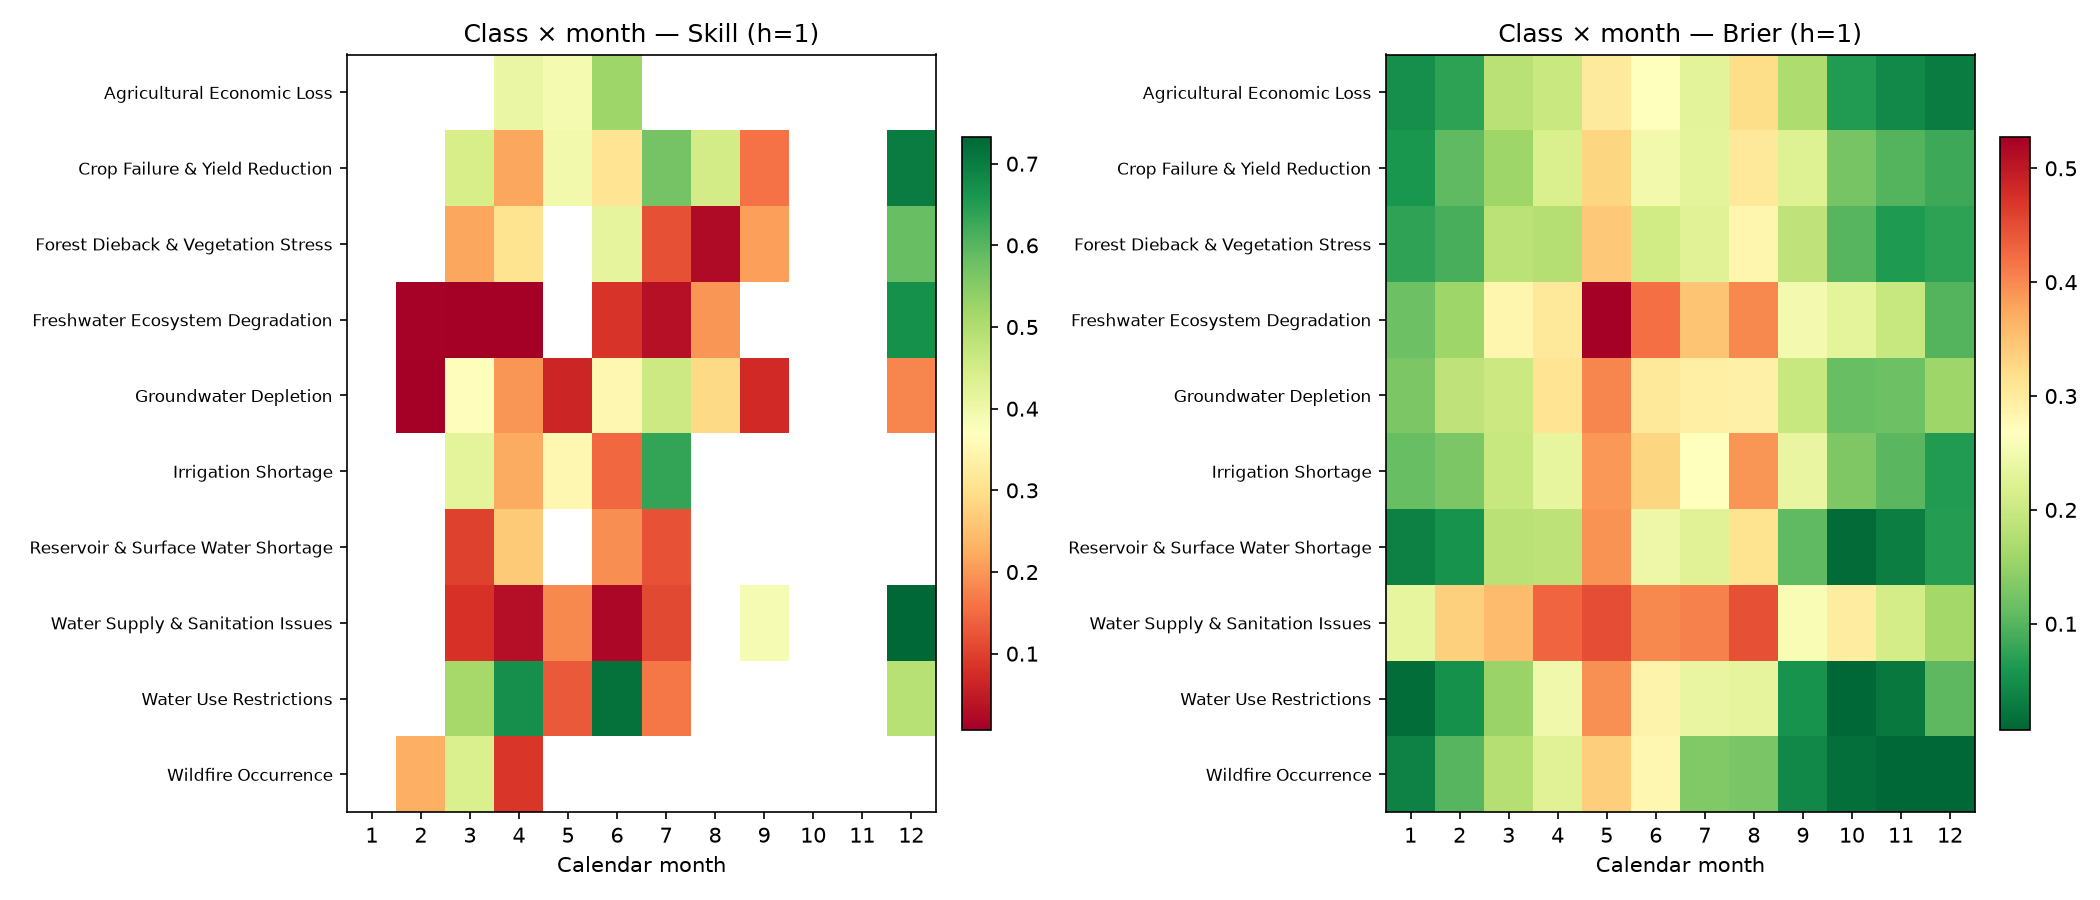

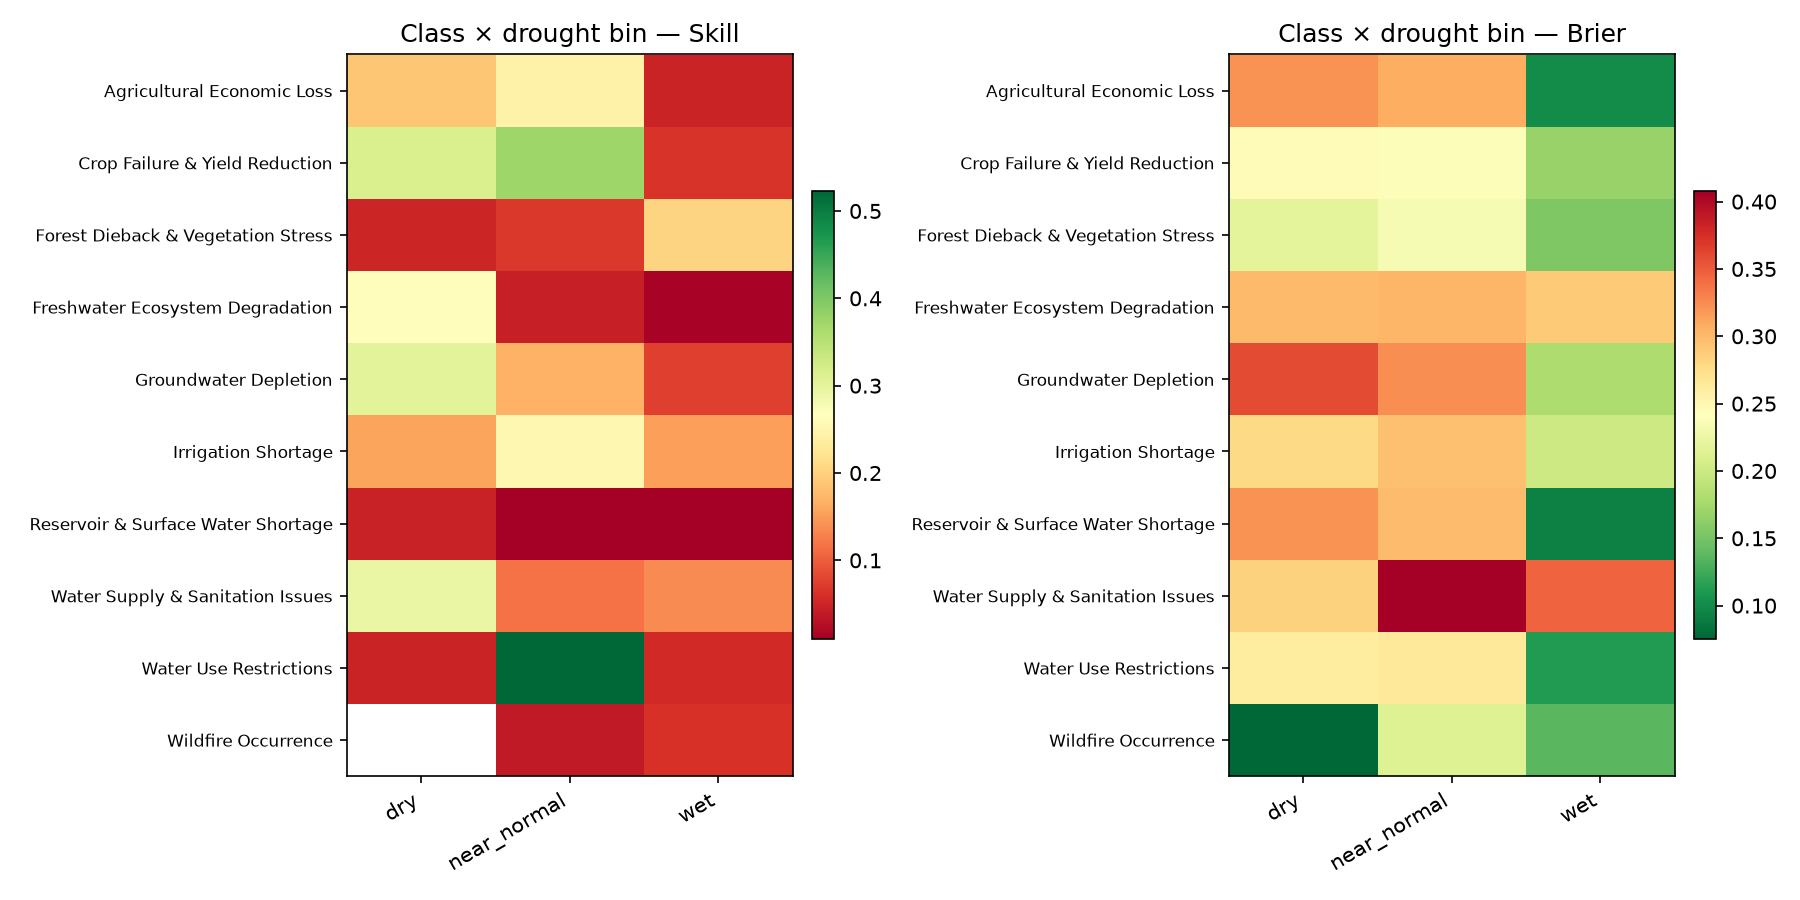

In [15]:
class_cal = pd.read_csv(RESULT_DIR / "diag_class_by_calendar_month.csv")
class_dry = pd.read_csv(RESULT_DIR / "diag_class_by_drought_bin.csv")
top_bottom = pd.read_csv(RESULT_DIR / "diag_class_nuts3_top_bottom.csv")

print("Class × drought bin (skill):")
display(
    class_dry.pivot(index="class", columns="drought_bin", values="skill")
    .reindex(columns=["dry", "near_normal", "wet"])
    .round(4)
)

print("\nTop/bottom regions per class (sample):")
display(top_bottom.head(24).round(4))

from IPython.display import Image, display as idisplay

for name in [
    "fig_diag_class_by_calendar_month.png",
    "fig_diag_class_by_drought_bin.png",
]:
    idisplay(Image(filename=str(FIG_DIR / name)))


### 6.4 Regional performance in JJA (Jun / Jul / Aug)

Restrict the test set to summer months and recompute per-NUTS-3 metrics. Compare ranks vs the all-months regional table.


Best JJA regions:


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos
0,NL332,Agglomeratie ’s-Gravenhage,NaN,NaN,0.1341,5.0
1,NL132,Zuidoost-Drenthe,NaN,NaN,0.1415,1.0
2,NL33B,Oost-Zuid-Holland,NaN,NaN,0.1498,4.0
3,NL325,Zaanstreek,NaN,NaN,0.1501,7.0
4,NL323,IJmond,NaN,NaN,0.1529,6.0
5,NL125,Zuidwest-Friesland,NaN,NaN,0.1617,4.0
6,NL324,Agglomeratie Haarlem,NaN,NaN,0.1754,7.0
7,NL126,Zuidoost-Friesland,NaN,NaN,0.1873,1.0



Worst JJA regions:


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos
32,NL421,Noord-Limburg,NaN,NaN,0.4014,11.0
33,NL414,Zuidoost-Noord-Brabant,NaN,NaN,0.4064,19.0
34,NL413,Noordoost-Noord-Brabant,NaN,NaN,0.4084,15.0
35,NL212,Zuidwest-Overijssel,NaN,NaN,0.4243,7.0
36,NL213,Twente,NaN,NaN,0.4373,12.0
37,NL422,Midden-Limburg,NaN,NaN,0.4417,9.0
38,NL225,Achterhoek,NaN,NaN,0.4824,8.0
39,NL221,Veluwe,NaN,NaN,0.5270,8.0



Largest skill drops in JJA vs all months:


,nuts3_id,nuts3_name,skill_all,skill_jja,delta_skill_jja_minus_all,brier_all,brier_jja
0,NL111,Oost-Groningen,NaN,NaN,NaN,0.1491,0.2150
1,NL112,Delfzijl en omgeving,NaN,NaN,NaN,0.2074,0.2908
2,NL113,Overig Groningen,NaN,NaN,NaN,0.1465,0.2292
3,NL124,Noord-Friesland,NaN,NaN,NaN,0.1962,0.2842
4,NL125,Zuidwest-Friesland,NaN,NaN,NaN,0.1200,0.1617
5,NL126,Zuidoost-Friesland,NaN,NaN,NaN,0.1316,0.1873
6,NL131,Noord-Drenthe,NaN,NaN,NaN,0.1861,0.2856
7,NL132,Zuidoost-Drenthe,NaN,NaN,NaN,0.0895,0.1415
8,NL133,Zuidwest-Drenthe,NaN,NaN,NaN,0.1376,0.2153
9,NL211,Noord-Overijssel,NaN,NaN,NaN,0.1644,0.2300


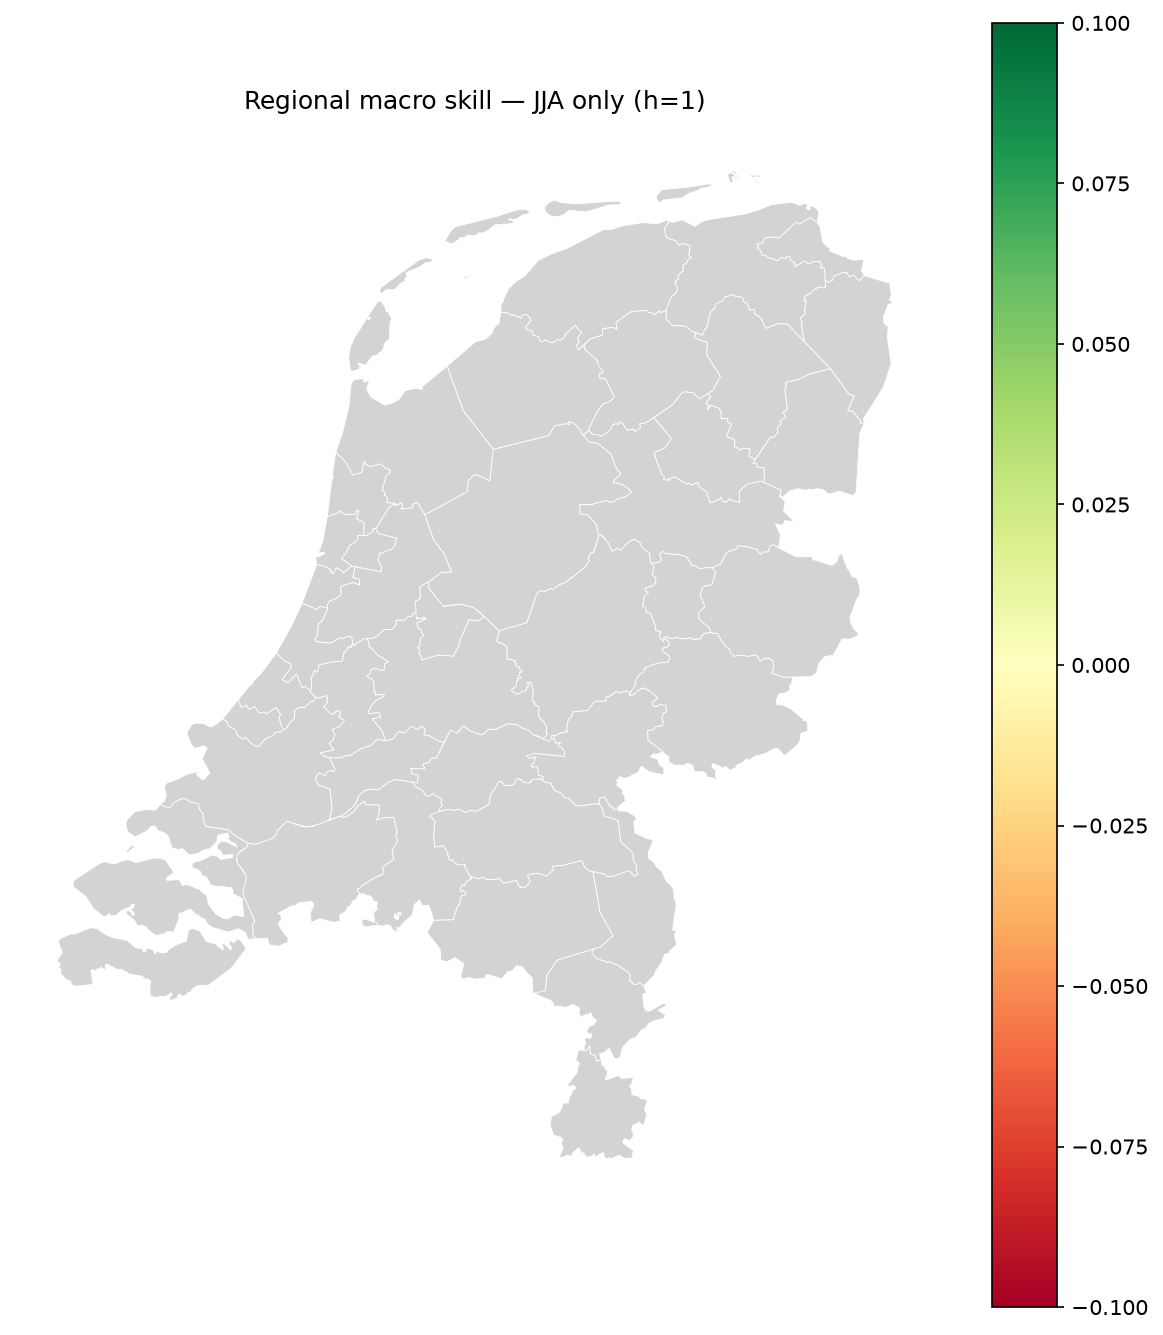

In [16]:
jja = pd.read_csv(RESULT_DIR / "diag_spatial_jja_by_nuts3.csv")
cmp = pd.read_csv(RESULT_DIR / "diag_spatial_all_vs_jja.csv")

print("Best JJA regions:")
display(jja.head(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos"]].round(4))
print("\nWorst JJA regions:")
display(jja.tail(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos"]].round(4))

print("\nLargest skill drops in JJA vs all months:")
display(
    cmp.assign(abs_delta=lambda d: d["delta_skill_jja_minus_all"].abs())
    .sort_values("delta_skill_jja_minus_all")
    .head(10)[
        ["nuts3_id", "nuts3_name", "skill_all", "skill_jja", "delta_skill_jja_minus_all", "brier_all", "brier_jja"]
    ]
    .round(4)
)

from IPython.display import Image, display as idisplay

jja_map = FIG_DIR / "fig_spatial_skill_choropleth_jja.png"
if jja_map.exists():
    idisplay(Image(filename=str(jja_map)))
else:
    print("JJA choropleth missing.")


## 7. Summary


In [17]:
summary = {
    "best_model": best.model_name,
    "cv_macro_pr_auc_h1": best.cv_macro_pr_auc,
    "n_features": len(best.features),
    "feature_groups": best.feature_groups_used,
    "group_subsets": best.group_subsets,
    "n_trials": N_TRIALS,
    "test_macro_pr_auc_by_horizon": {
        int(r.horizon): float(r.macro_pr_auc) for r in macro_test.itertuples()
    },
}
print(json.dumps(summary, indent=2))
(RESULT_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("\nExports written to:", RESULT_DIR)
for p in sorted(RESULT_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(RESULT_DIR))


{
  "best_model": "logistic_regression",
  "cv_macro_pr_auc_h1": 0.33501974879731256,
  "n_features": 30,
  "feature_groups": [
    "meteo",
    "temporal",
    "static_elev",
    "static_soil"
  ],
  "group_subsets": {
    "meteo": "long",
    "temporal": "seasonality",
    "static_elev": "both",
    "static_soil": "all"
  },
  "n_trials": 100,
  "test_macro_pr_auc_by_horizon": {
    "0": 0.3032924269760578,
    "1": 0.25899714831794,
    "2": 0.22482878155342295,
    "3": 0.23032513817508105
  }
}

Exports written to: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results
 - best_config.json
 - best_config_cv_folds.csv
 - cv_trials.csv
 - diag_class_by_calendar_month.csv
 - diag_class_by_drought_bin.csv
 - diag_class_by_nuts3.csv
 - diag_class_nuts3_top_bottom.csv
 - diag_prediction_long_h1.csv
 - diag_spatial_all_vs_jja.csv
 - diag_spatial_by_nuts3.csv
 - diag_